In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../Data/Cleaned/customer_churn_dataset.csv")
df.head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1.0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0
1,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
2,2.0,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0
3,3.0,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0
4,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0


## Feature Engineering 

In [3]:
import numpy as np

df["Issue_Level"] = np.where(
    df["Support Calls"] <= 2,
    "Low Issues",
    np.where(df["Support Calls"] <= 4,
             "Medium Issues",
             "High Issues")
)

df["Delay_Level"] = np.where(
    df["Payment Delay"] <= 15,
    "Low Delay",
    np.where(df["Payment Delay"] <= 20,
             "Medium Delay",
             "High Delay")
)

df["Spend_Level"] = np.where(
    df["Total Spend"] <= 508,
    "Low Spend",
    "High Spend"
)

- These thresholds were chosen from SQL analysis

## Dummy Encoding and train-test Split

In [45]:
# Original Features
X_original = df[
    [
        "Issue_Level",
        "Delay_Level",
        "Spend_Level",
        "Contract Length"
    ]
]

# Encoded Features
X_encoded = pd.get_dummies(
    X_original,
    drop_first=True,
    dtype=int
)

# Target
y = df["Churn"]

from sklearn.model_selection import train_test_split

(
    X_train,
    X_test,
    X_train_original,
    X_test_original,
    y_train,
    y_test
) = train_test_split(
    X_encoded,
    X_original,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Hyperparameter tuning

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Base model
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    
)

# Hyperparameters
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    
    "class_weight": [None, "balanced"]
}

# Grid Search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'C': 0.1, 'class_weight': None}
Best CV Accuracy: 0.8865188365886839


#### Observation and conclusion
- The best performing parameters are {'C': 0.1, 'class_weight': None}
- The CV accuracy is 0.88


## Evaluation Metric Analysis

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Prediction
y_pred = best_model.predict(X_test)

# Probability Prediction
y_prob = best_model.predict_proba(X_test)[:,1]

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8851566675243958
Precision: 0.887634380499364
Recall   : 0.9081088789461488
F1 Score : 0.8977549078349135
ROC AUC  : 0.9196271271405951

Confusion Matrix
[[38494  6449]
 [ 5155 50944]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87     44943
         1.0       0.89      0.91      0.90     56099

    accuracy                           0.89    101042
   macro avg       0.88      0.88      0.88    101042
weighted avg       0.89      0.89      0.88    101042



#### Observation and conclusion
|        | Predicted 0 | Predicted 1 |
|--------|------------:|------------:|
| Actual 0 | 38494 | 6449 |
| Actual 1 | 5155  | 50944 |

1. Logistic regression fails to predict 5155 churned customers.
    - The model classified churning customers as non-churning. So, no retention stratergies.
    - If the high value profile customers belongs to this can be fatal as we won't able to prevent their churn.
2. Logistic regression fails to predict 6449 non-churned customers.
    - The model classified non-churning customers as churning. 
    - The retention stratergies are applied on non-churning customers.
3.  Logistic regression predicted churned and non-churned customers with 0.88 accuracy
4. The Recall is 0.90 where precision is 0.88
    - Here, losing high value profile customers can be more fatal than applying retention stratergies on wrong customers
    - The recall should be overall greater than precision 
5. The F1 Score is 0.81.
6. To optimise for churned customers , we can lower the threshold.

#### ROC and AUC

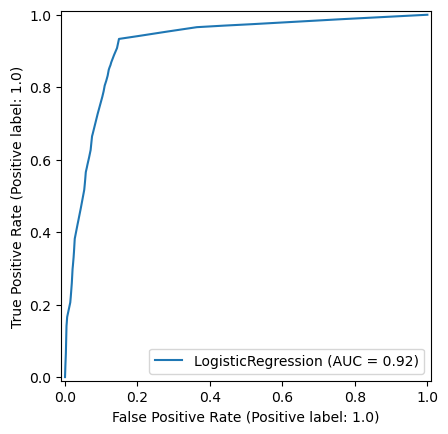

In [48]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

##### Observation and conclusion

An ROC-AUC score of 0.92 indicates that the model has excellent discriminative ability. It means that if one churn customer and one non-churn customer are selected at random, the model will assign a higher churn probability to the actual churn customer approximately 92% of the time.

## Segmentwise metric Evaluation

In [49]:
results = X_test_original.copy()

results["Actual"] = y_test.values
results["Predicted"] = y_pred

In [50]:
false_negative = results[
    (results["Actual"] == 1) &
    (results["Predicted"] == 0)
]

false_negative.head()

,Issue_Level,Delay_Level,Spend_Level,Contract Length,Actual,Predicted
130263,Medium Issues,Medium Delay,High Spend,Quarterly,1.0,0.0
194081,Medium Issues,Low Delay,High Spend,Quarterly,1.0,0.0
213143,Medium Issues,Medium Delay,High Spend,Quarterly,1.0,0.0
252515,Medium Issues,Low Delay,High Spend,Annual,1.0,0.0
92707,Medium Issues,Low Delay,High Spend,Annual,1.0,0.0


In [51]:
false_positive = results[
    (results["Actual"] == 0) &
    (results["Predicted"] == 1)
]

false_positive.head()

,Issue_Level,Delay_Level,Spend_Level,Contract Length,Actual,Predicted
5192,Medium Issues,Low Delay,High Spend,Monthly,0.0,1.0
50894,Medium Issues,Low Delay,Low Spend,Quarterly,0.0,1.0
90680,Low Issues,High Delay,High Spend,Annual,0.0,1.0
18573,Medium Issues,Low Delay,Low Spend,Monthly,0.0,1.0
82807,Medium Issues,Low Delay,Low Spend,Quarterly,0.0,1.0


In [52]:
fp_rate = (
    false_positive["Spend_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Spend_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Spend_Level
High Spend      7.03
Low Spend     100.00
Name: count, dtype: float64


In [53]:
fn_rate = (
    false_negative["Spend_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Spend_Level"].value_counts()
)

print((fn_rate * 100).round(2))

Spend_Level
High Spend    17.57
Low Spend       NaN
Name: count, dtype: float64


In [54]:
fp_rate = (
    false_positive["Issue_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Issue_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Issue_Level
High Issues      100.00
Low Issues         6.02
Medium Issues     10.90
Name: count, dtype: float64


In [55]:
fp_rate = (
    false_negative["Issue_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Issue_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Issue_Level
High Issues       NaN
Low Issues       24.6
Medium Issues    19.2
Name: count, dtype: float64


In [56]:
fp_rate = (
    false_positive["Delay_Level"].value_counts()
    /
    X_test_original[y_test == 0]["Delay_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Delay_Level
High Delay      100.00
Low Delay        12.58
Medium Delay      9.03
Name: count, dtype: float64


In [57]:
fp_rate = (
    false_negative["Delay_Level"].value_counts()
    /
    X_test_original[y_test == 1]["Delay_Level"].value_counts()
)

print((fp_rate * 100).round(2))

Delay_Level
High Delay        NaN
Low Delay       16.50
Medium Delay     9.76
Name: count, dtype: float64


In [58]:
fp_rate = (
    false_negative["Contract Length"].value_counts()
    /
    X_test_original[y_test == 1]["Contract Length"].value_counts()
)

print((fp_rate * 100).round(2))

Contract Length
Annual       10.54
Monthly       7.20
Quarterly     9.98
Name: count, dtype: float64


In [59]:
fp_rate = (
    false_positive["Contract Length"].value_counts()
    /
    X_test_original[y_test == 0]["Contract Length"].value_counts()
)

print((fp_rate * 100).round(2))

Contract Length
Annual       10.67
Quarterly    10.54
Monthly      88.72
Name: count, dtype: float64


#### Observations for False Negatives

1. The model misses 10.54%, 7.20% and 9.98% Annual, Monthly and Quarterly Churning Customers.
2. The model misses 0%, 16.5% and 9.76% High, Low and Medium delay Churning Customers.
3. The model misses 0%, 24.6% and 19.2% High, Low and Medium Issues Churnning Customers.
4. The model misses 0% and 17.57% High and Low Spending Churnning Customers.

#### Conclusion

- The model's false negatives are primarily concentrated among high-value customers with Quarterly/Annual contracts, low to medium payment delays, and low to medium support issues. Since these customers appear relatively healthy despite eventually churning, the model fails to identify them as at risk. Losing these customers can be particularly costly because they contribute higher revenue and may have greater customer lifetime value.

#### Observations for False positives

1. The model misses 10.67%, 88.72% and 10.54% Annual, Monthly and Quarterly Non-churning Customers.
2. The model misses 100%, 12.58% and 9.03% High, Low and Medium delay Non-churning Customers.
3. The model misses 100%, 6.02% and 10.09% High, Low and Medium Issues Non-churning Customers.
4. The model misses 7.03% and 100% High and Low Spending Non-churning customers.

#### Conclusion

- Applying the retention stratergies on missed non-churning low spend,monthly contract length low value profile customers can lead to a buisness loss.

- The model appears to rely heavily on strong churn indicators such as high payment delays or frequent support issues. Customers who churned without exhibiting these dominant patterns were more likely to be misclassified as non-churn.